Missing states filled: set()
Total states in map: 50
States: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']


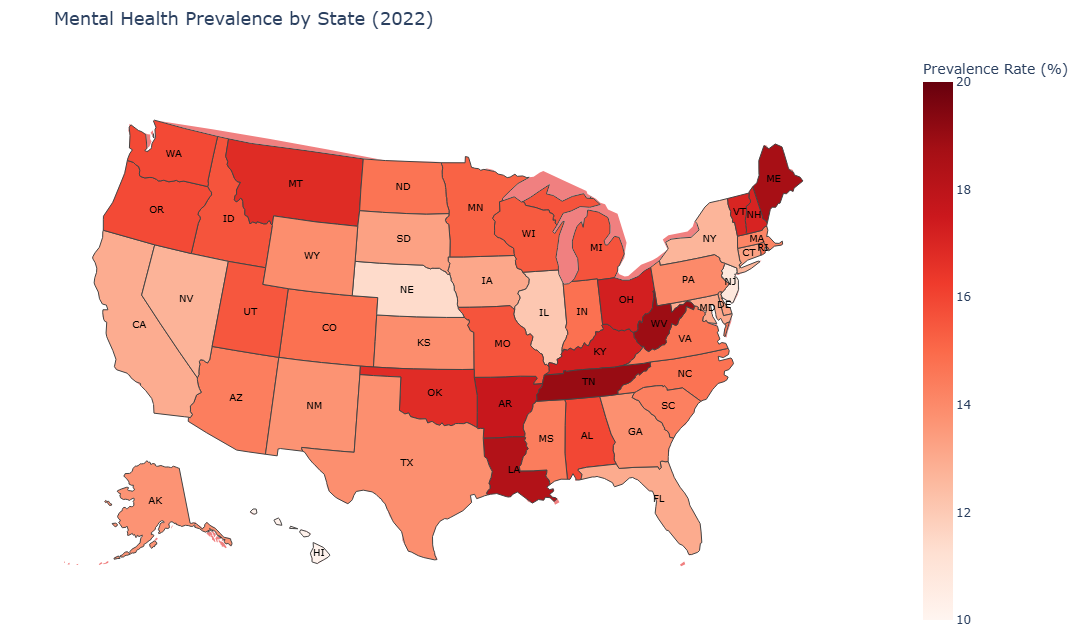

HTML saved!


In [22]:

import pandas as pd
import plotly.express as px

df = pd.read_csv('../data/processed/mental_health_clean.csv')

# Step 1 — Get 2022 and 2021 data
df_2022 = df[df['YearStart'] == 2022].groupby('LocationAbbr')['DataValue'].mean().reset_index()
df_2021 = df[df['YearStart'] == 2021].groupby('LocationAbbr')['DataValue'].mean().reset_index()

# Step 2 — Fill missing states with 2021 data
missing = set(df_2021['LocationAbbr']) - set(df_2022['LocationAbbr'])
print("Missing states filled:", missing)
fill = df_2021[df_2021['LocationAbbr'].isin(missing)]
map_df = pd.concat([df_2022, fill], ignore_index=True)

# Step 3 — Keep only 50 states
states_50 = ['AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA',
             'HI','ID','IL','IN','IA','KS','KY','LA','ME','MD',
             'MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
             'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC',
             'SD','TN','TX','UT','VT','VA','WA','WV','WI','WY']

map_df = map_df[map_df['LocationAbbr'].isin(states_50)]
print("Total states in map:", len(map_df))
print("States:", map_df['LocationAbbr'].tolist())

# Step 4 — Plot
fig = px.choropleth(map_df,
                    locations='LocationAbbr',
                    locationmode='USA-states',
                    color='DataValue',
                    scope='usa',
                    color_continuous_scale='Reds',
                    range_color=[10, 20],
                    title='Mental Health Prevalence by State (2022)',
                    labels={'DataValue': 'Prevalence Rate (%)'})

fig.add_scattergeo(
    locations=map_df['LocationAbbr'],
    locationmode='USA-states',
    text=map_df['LocationAbbr'],
    mode='text',
    textfont=dict(size=10, color='black'),
    showlegend=False
)

fig.update_layout(
    geo=dict(
        scope='usa',
        bgcolor='white',      # Change lakes to white
        landcolor='lightcoral', # Keep land gap fill
        showlakes=False         # Hide lakes completely
    ),
    width=1100,
    height=600,
    title_font_size=18,
    margin=dict(l=0, r=0, t=50, b=0),
    paper_bgcolor='white'
)

fig.show()

# Step 5 — Save HTML
fig.write_html('../visuals/choropleth_map_2022.html')
print("HTML saved!")

2019 states: 50
2022 states: 50


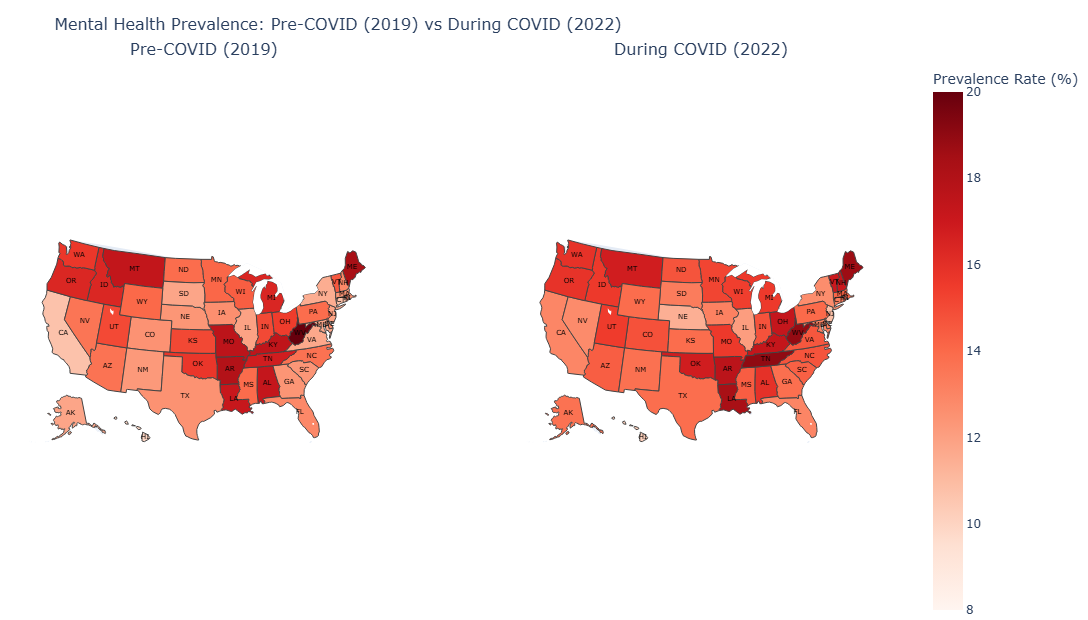

 Comparison map saved!


In [25]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd

df = pd.read_csv('../data/processed/mental_health_clean.csv')

# 50 states only
states_50 = ['AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA',
             'HI','ID','IL','IN','IA','KS','KY','LA','ME','MD',
             'MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
             'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC',
             'SD','TN','TX','UT','VT','VA','WA','WV','WI','WY']

# Get 2019 and 2022 data
df_2019 = df[df['YearStart'] == 2019].groupby('LocationAbbr')['DataValue'].mean().reset_index()
df_2022 = df[df['YearStart'] == 2022].groupby('LocationAbbr')['DataValue'].mean().reset_index()

# Filter to 50 states only
df_2019 = df_2019[df_2019['LocationAbbr'].isin(states_50)]
df_2022 = df_2022[df_2022['LocationAbbr'].isin(states_50)]

print("2019 states:", len(df_2019))
print("2022 states:", len(df_2022))

# Create side by side subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Pre-COVID (2019)', 'During COVID (2022)'),
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}]]
)

# 2019 choropleth
fig.add_trace(go.Choropleth(
    locations=df_2019['LocationAbbr'],
    z=df_2019['DataValue'],
    locationmode='USA-states',
    colorscale='Reds',
    zmin=8, zmax=20,
    showscale=False,
    name='2019'
), row=1, col=1)

# 2019 state labels
fig.add_trace(go.Scattergeo(
    locations=df_2019['LocationAbbr'],
    locationmode='USA-states',
    text=df_2019['LocationAbbr'],
    mode='text',
    textfont=dict(size=7, color='black'),
    showlegend=False
), row=1, col=1)

# 2022 choropleth
fig.add_trace(go.Choropleth(
    locations=df_2022['LocationAbbr'],
    z=df_2022['DataValue'],
    locationmode='USA-states',
    colorscale='Reds',
    zmin=8, zmax=20,
    colorbar_title='Prevalence Rate (%)',
    name='2022'
), row=1, col=2)

# 2022 state labels
fig.add_trace(go.Scattergeo(
    locations=df_2022['LocationAbbr'],
    locationmode='USA-states',
    text=df_2022['LocationAbbr'],
    mode='text',
    textfont=dict(size=7, color='black'),
    showlegend=False
), row=1, col=2)

# Update layout
fig.update_geos(scope='usa')
fig.update_layout(
    title_text='Mental Health Prevalence: Pre-COVID (2019) vs During COVID (2022)',
    title_font_size=16,
    width=1400,
    height=600,
    margin=dict(l=0, r=0, t=60, b=0),
    paper_bgcolor='white'
)

fig.show()

# Save
fig.write_html('../visuals/comparison_map.html')
print(" Comparison map saved!")